In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the masters degree dataset
df_masters = pd.read_csv("/Users/thetsusann/Desktop/BIA/Project/EDA/datasets/mastersportal-programs.csv")
df_masters_us = df_masters[df_masters["country_name"] == "United States"].copy()
df_masters_us.head()

,country_name,country_code,university_name,university_rank,program_name,program_type,deadline,duration,language,tution_1_currency,...,tution_2_money,tution_2_type,tuition_price_specification,start_date,ielts_score,structure,academic_req,facts,city,program_url
36330,United States,USA,Abilene Christian University,NaN,Ancient and Oriental Christianity,MA,2011-08-18T00:00:00Z,24 months,English,USD,...,30576.0,National,Tuition (Full programme),2018-08-28 00:00:00,NaN,['History of Christianity I: Early and Medieva...,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-28 00:00:00 You can...,"['Abilene', 'United States']",http://www.mastersportal.eu/studies/185014/anc...
36331,United States,USA,Abilene Christian University,NaN,Christian Ministry,MA,2011-08-18T00:00:00Z,24 months,English,USD,...,30576.0,National,Tuition (Full programme),2018-08-28 00:00:00,NaN,"['Biblical Exegesis', 'History of Christianity...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-28 00:00:00 You can...,"['Abilene', 'United States']",http://www.mastersportal.eu/studies/185022/chr...
36332,United States,USA,Abilene Christian University,NaN,Divinity,MDiv,2011-08-18T00:00:00Z,48 months,English,USD,...,45864.0,National,Tuition (Full programme),2018-08-28 00:00:00,NaN,"['Foundations of the Theology of Ministry', 'N...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-28 00:00:00 You can...,"['Abilene', 'United States']",http://www.mastersportal.eu/studies/185069/div...
36333,United States,USA,Abilene Christian University,NaN,English,MA,2011-08-18T00:00:00Z,24 months,English,USD,...,41328.0,National,Tuition (Full programme),2018-08-28 00:00:00,NaN,"['Literary Theory and Faith', 'Business and Pr...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-28 00:00:00 You can...,"['Abilene', 'United States']",http://www.mastersportal.eu/studies/184985/eng...
36334,United States,USA,Abilene Christian University,NaN,Modern and American Christianity,MA,2011-08-18T00:00:00Z,24 months,English,USD,...,30576.0,National,Tuition (Full programme),2018-08-28 00:00:00,NaN,"['Issues in Global Christianity', 'History of ...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-28 00:00:00 You can...,"['Abilene', 'United States']",http://www.mastersportal.eu/studies/185010/mod...


In [5]:
# Some overall insights
print("Total programs (all countries):", df_masters.shape[0])
print("US programs:", df_masters_us.shape[0])
print("Unique program titles (US):", df_masters_us["program_name"].nunique())
print("Unique universities (US):", df_masters_us["university_name"].nunique())
print("Unique cities (US):", df_masters_us["city"].nunique())

Total programs (all countries): 60425
US programs: 24084
Unique program titles (US): 9367
Unique universities (US): 669
Unique cities (US): 436


/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/270340685.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


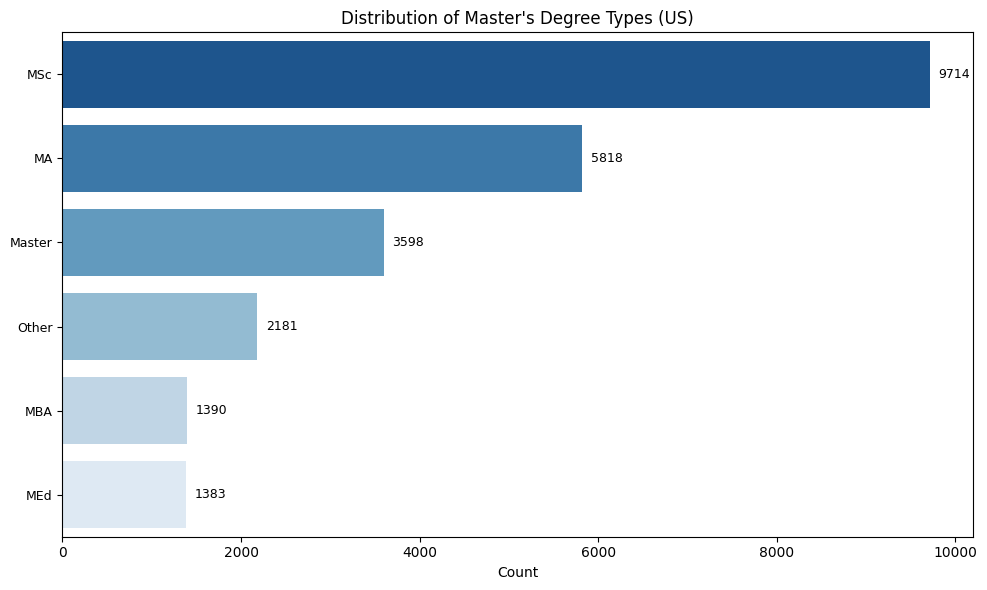

In [9]:
# Degree type distribution with small categories grouped as 'Other'
# Group categories with low counts into 'Other' to improve readability
total = len(df_masters_us)
min_count = max(3, int(0.02 * total))  # at least 3 or 2% of rows
vc = df_masters_us['program_type'].value_counts()
small_cats = vc[vc < min_count].index.tolist()
df_plot = df_masters_us.copy()
df_plot['program_type_grouped'] = df_plot['program_type'].where(~df_plot['program_type'].isin(small_cats), 'Other')
counts = df_plot['program_type_grouped'].value_counts()
fig_height = max(6, 0.4 * len(counts))
plt.figure(figsize=(10, fig_height))
ax = sns.countplot(
    data=df_plot,
    y="program_type_grouped",
    order=counts.index,
    palette="Blues_r"
)
plt.title("Distribution of Master's Degree Types (US)")
plt.xlabel("Count")
plt.ylabel("")
plt.yticks(fontsize=9)
plt.xticks(rotation=0)
# Annotate bars with counts
max_count = counts.max() if len(counts) > 0 else 0
for p in ax.patches:
    width = p.get_width()
    ax.text(width + max_count * 0.01, p.get_y() + p.get_height() / 2,
            f'{int(width)}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/964970574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


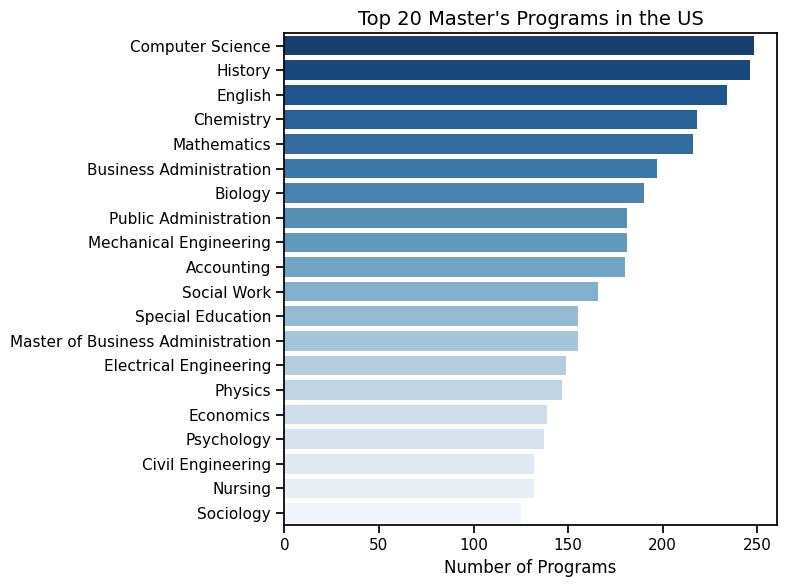

,Occupation,Probability
0,Recreational Therapists,0.0028
1,First-Line Supervisors of Mechanics; Installer...,0.0030
2,Emergency Management Directors,0.0030
3,Mental Health and Substance Abuse Social Workers,0.0031
4,Audiologists,0.0033
5,Healthcare Social Workers,0.0035
6,Occupational Therapists,0.0035
7,Orthotists and Prosthetists,0.0035
8,Oral and Maxillofacial Surgeons,0.0036
9,First-Line Supervisors of Fire Fighting and Pr...,0.0036


In [32]:
# Most common program titles in the US
top_programs = df_masters_us["program_name"].value_counts().head(20)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_programs.values,
    y=top_programs.index,
    palette="Blues_r"
)
plt.title("Top 20 Master's Programs in the US")
plt.xlabel("Number of Programs")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [13]:
# Classify programs into broader fields based on keywords in the program name
import re
def classify_field(name: str) -> str:
    if not name or pd.isna(name):
        return "Other"
    n = name.lower()

    # Priority-ordered categories with representative keywords
    mapping = {
        "Engineering": ["engineering", "engineer", "mechanical", "electrical", "civil", "chemical", "aerospace", "industrial", "systems"],
        "Computing & Data": ["computer", "comput", "data", "information", "informatics", "ai", "artificial intelligence", "machine learning", "software", "cyber"],
        "Business & Management": ["business", "management", "mba", "marketing", "finance", "accounting", "strategy", "entrepreneur"],
        "Economics & Finance": ["economics", "economy", "financial", "finance", "actuarial"],
        "Health & Medicine": ["health", "nursing", "medical", "medicine", "public health", "biomedical", "pharmacy", "clinical"],
        "Education": ["education", "teaching", "curriculum", "pedagog"],
        "Natural Sciences": ["science", "biology", "chemistry", "physics", "mathematics", "math", "geology", "astronomy"],
        "Social Sciences": ["psychology", "sociology", "political", "anthropology", "international relations", "public policy", "policy"],
        "Law & Public Policy": ["law", "legal", "jurisprudence", "public policy", "policy"],
        "Arts & Humanities": ["art", "arts", "music", "design", "humanities", "philosophy", "literature", "history", "language"],
        "Design & Architecture": ["design", "architecture", "urban", "landscape", "interior"],
        "Environmental & Agricultural": ["environment", "environmental", "sustainability", "agriculture", "agricultural", "forestry"],
        "Interdisciplinary": ["interdisciplinary", "multidisciplinary", "cross[- ]disciplin"],
    }

    # check categories in order; use regex word boundaries for safer matching
    for category, keywords in mapping.items():
        for kw in keywords:
            try:
                if re.search(r"\b" + kw + r"\b", n):
                    return category
            except re.error:
                # fallback to simple substring if regex fails (e.g., contains special chars)
                if kw in n:
                    return category

    # fallback heuristics: look for common acronyms or short tokens
    if any(t in n for t in ["msc", "ms", "m.sc", "m.s."]):
        return "Other"

    return "Other"

# Apply and inspect distribution
df_masters_us["broad_field"] = df_masters_us["program_name"].astype(str).apply(classify_field)
df_masters_us["broad_field"].value_counts()

broad_field
Other                           7839
Business & Management           2836
Education                       2662
Engineering                     2485
Natural Sciences                2077
Arts & Humanities               1879
Health & Medicine               1634
Social Sciences                  941
Computing & Data                 797
Economics & Finance              317
Design & Architecture            244
Environmental & Agricultural     197
Law & Public Policy              143
Interdisciplinary                 33
Name: count, dtype: int64

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/507384479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


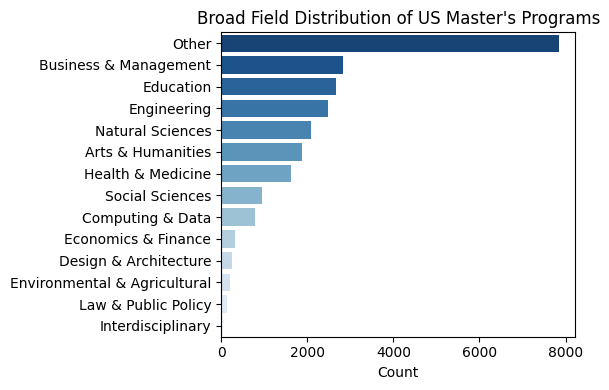

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_masters_us,
    y="broad_field",
    order=df_masters_us["broad_field"].value_counts().index,
    palette="Blues_r"
)
plt.title("Broad Field Distribution of US Master's Programs")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/1818047324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


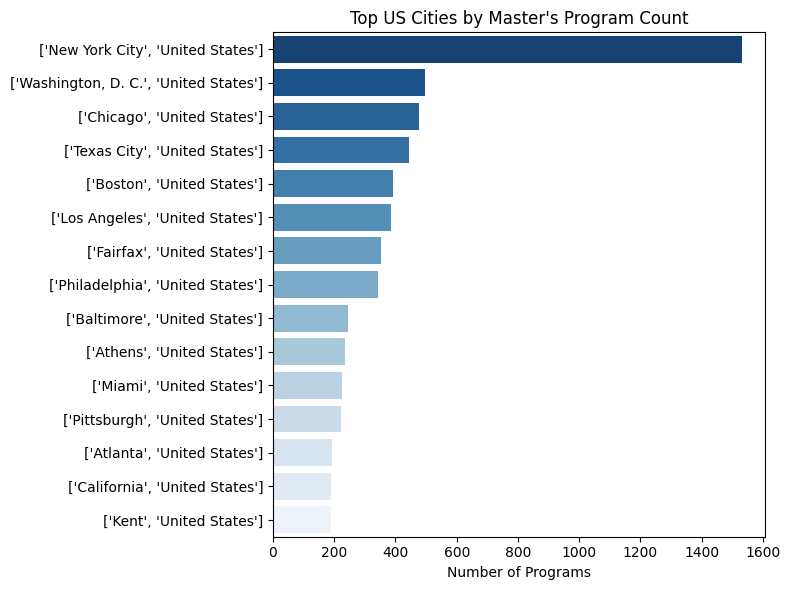

In [15]:
# Top cities by number of master's programs in the US
top_cities = df_masters_us["city"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    palette="Blues_r"
)
plt.title("Top US Cities by Master's Program Count")
plt.xlabel("Number of Programs")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [19]:
# Load automation dataset
df_automation = pd.read_csv("/Users/thetsusann/Desktop/BIA/Project/EDA/datasets/automation-data-by-state.csv", encoding="cp1252")
df_automation.head()

,SOC,Occupation,Probability,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,11-1011,Chief Executives,0.015,1030,760,5750,2710,31150,880,1410,...,560,5460,5890,3650,280,6320,5910,980,3740,160
1,11-1021,General and Operations Managers,0.160,26930,6490,43300,20680,261780,41540,33280,...,3730,44400,168610,36200,2760,52380,43760,10200,32350,4840
2,11-2011,Advertising and Promotions Managers,0.039,50,40,470,110,3760,480,300,...,0,670,1210,380,40,240,640,40,200,0
3,11-2021,Marketing Managers,0.014,530,200,4790,1090,33390,3060,4970,...,60,3400,9570,2320,380,3840,5830,260,2980,30
4,11-2022,Sales Managers,0.013,2510,400,10650,2650,69180,4570,7040,...,300,8890,22310,3360,480,5360,7390,600,5730,180


In [33]:
# Basics
print("Total occupations in automation dataset:", df_automation.shape[0])
print("Unique SOC codes:", df_automation["SOC"].nunique())
print("Missing probabilities:", df_automation["Probability"].isna().sum())

# Show mapping from SOC code → Occupation description
# This prints all unique SOC values and the corresponding occupation labels so you can see which number maps to which description
mapping = df_automation[["SOC", "Occupation"]].drop_duplicates().copy()
# Normalize SOC as string and strip whitespace
mapping['SOC'] = mapping['SOC'].astype(str).str.strip()
mapping = mapping.sort_values('SOC')
from IPython.display import display
print("Number of unique SOC → Occupation pairs:", mapping.shape[0])
display(mapping.reset_index(drop=True))

# If you want to look up a specific SOC number, set soc = '...' and run the next line
# Example: soc = '15-1252' or soc = '151252' depending on your SOC format
# soc = '15-1252'
# display(mapping[mapping['SOC'].str.contains(soc)])

Total occupations in automation dataset: 702
Unique SOC codes: 702
Missing probabilities: 0
Number of unique SOC → Occupation pairs: 702


Total occupations in automation dataset: 702
Unique SOC codes: 702
Missing probabilities: 0
Number of unique SOC → Occupation pairs: 702


,SOC,Occupation
0,11-1011,Chief Executives
1,11-1021,General and Operations Managers
2,11-2011,Advertising and Promotions Managers
3,11-2021,Marketing Managers
4,11-2022,Sales Managers
...,...,...
697,53-7072,Pump Operators; Except Wellhead Pumpers
698,53-7073,Wellhead Pumpers
699,53-7081,Refuse and Recyclable Material Collectors
700,53-7111,Mine Shuttle Car Operators


In [21]:
df_automation["Probability"].describe()

count    702.000000
mean       0.535550
std        0.368149
min        0.002800
25%        0.110000
50%        0.640000
75%        0.890000
max        0.990000
Name: Probability, dtype: float64

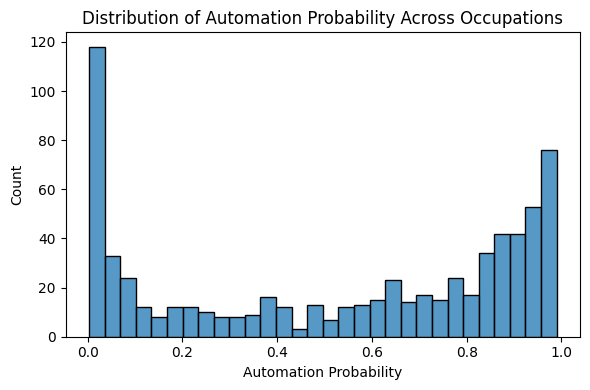

In [22]:
# Distribution of automation probabilities
plt.figure(figsize=(6,4))
sns.histplot(df_automation["Probability"], bins=30)
plt.title("Distribution of Automation Probability Across Occupations")
plt.xlabel("Automation Probability")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/2500159638.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Probability', y='label', data=top10, palette='Greens_r', order=top10['label'])


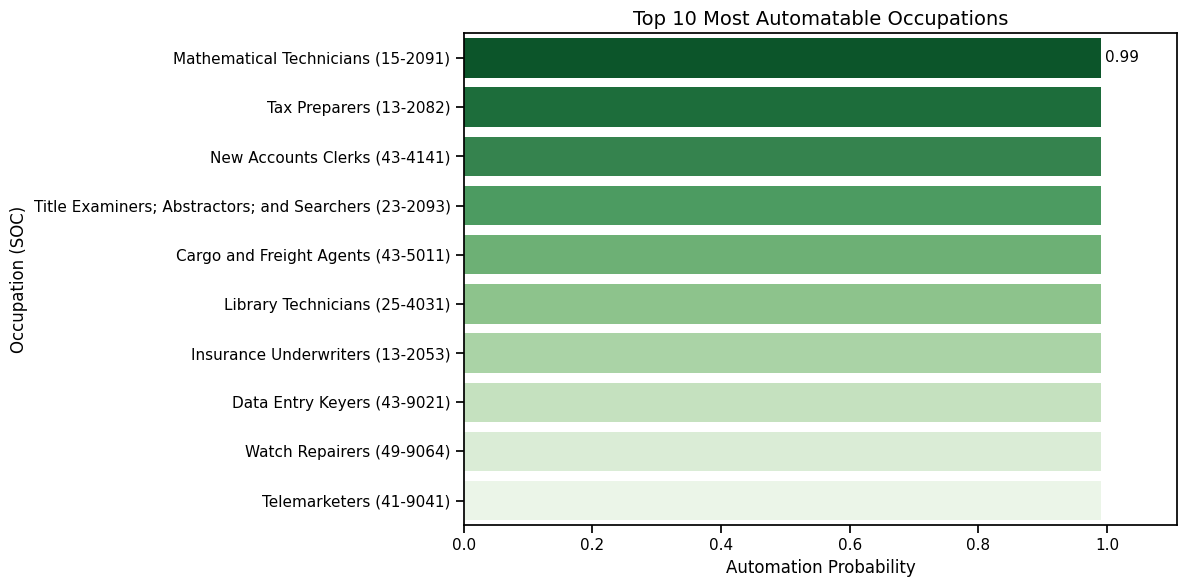

,Occupation,SOC,Probability
0,Mathematical Technicians,15-2091,99.0%
1,Tax Preparers,13-2082,99.0%
2,New Accounts Clerks,43-4141,99.0%
3,Title Examiners; Abstractors; and Searchers,23-2093,99.0%
4,Cargo and Freight Agents,43-5011,99.0%
5,Library Technicians,25-4031,99.0%
6,Insurance Underwriters,13-2053,99.0%
7,Data Entry Keyers,43-9021,99.0%
8,Watch Repairers,49-9064,99.0%
9,Telemarketers,41-9041,99.0%


Plotly not available - to enable interactive charts run: pip install plotly


In [34]:
# Top 10 most automatable occupations (horizontal bar chart)
top10 = df_automation.sort_values("Probability", ascending=False)[["Occupation", "Probability"]].head(10).copy()
# Ensure numeric
top10['Probability'] = pd.to_numeric(top10['Probability'], errors='coerce')
# Sort ascending for horizontal bar chart
top10 = top10.sort_values('Probability')
plt.figure(figsize=(10,6))
sns.barplot(x='Probability', y='Occupation', data=top10, palette='Reds_r')
plt.title('Top 10 Most Automatable Occupations')
plt.xlabel('Automation Probability')
plt.ylabel('Occupation')
# Annotate bars with probability values
for i, prob in enumerate(top10['Probability']):
    plt.text(prob + 0.01, i, f'{prob:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/2037667305.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Probability', y='label', data=bottom10, palette='Greens_r', order=bottom10['label'])


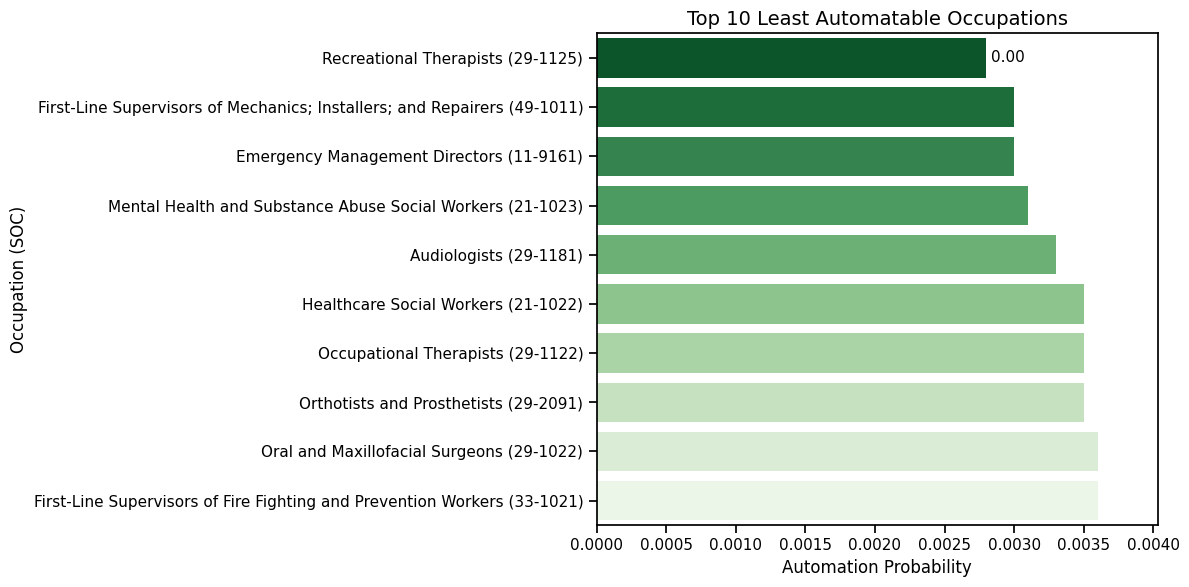

,Occupation,SOC,Probability
0,Recreational Therapists,29-1125,0.3%
1,First-Line Supervisors of Mechanics; Installer...,49-1011,0.3%
2,Emergency Management Directors,11-9161,0.3%
3,Mental Health and Substance Abuse Social Workers,21-1023,0.3%
4,Audiologists,29-1181,0.3%
5,Healthcare Social Workers,21-1022,0.4%
6,Occupational Therapists,29-1122,0.4%
7,Orthotists and Prosthetists,29-2091,0.4%
8,Oral and Maxillofacial Surgeons,29-1022,0.4%
9,First-Line Supervisors of Fire Fighting and Pr...,33-1021,0.4%


Plotly not available - to enable interactive charts run: pip install plotly


In [35]:
# Top 10 Least Automatable Occupations (green palette, improved annotations)
bottom10 = df_automation.sort_values("Probability", ascending=True)[["Occupation", "Probability"]].head(10).copy()
# Ensure numeric
bottom10['Probability'] = pd.to_numeric(bottom10['Probability'], errors='coerce')
# Sort ascending for horizontal bar chart (smallest at top)
bottom10 = bottom10.sort_values('Probability')
plt.figure(figsize=(12, max(6, 0.5 * len(bottom10))))
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
ax = sns.barplot(x='Probability', y='Occupation', data=bottom10, palette='Greens_r', order=bottom10['Occupation'])
plt.title('Top 10 Least Automatable Occupations')
plt.xlabel('Automation Probability')
plt.ylabel('Occupation')
# Add margin so annotations don't get clipped
ax.set_xlim(0, bottom10['Probability'].max() * 1.12)
# Annotate bars with probability values using bar_label if available
try:
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
except Exception:
    for i, prob in enumerate(bottom10['Probability']):
        plt.text(prob + 0.01, i, f'{prob:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [26]:
# Analyze automation probabilities by major SOC groups (first 2 digits)
df_automation["major_group"] = df_automation["SOC"].str[:2]

group_counts = df_automation["major_group"].value_counts().sort_index()
group_counts

major_group
11     31
13     30
15     15
17     34
19     42
21     13
23      8
25     22
27     36
29     44
31     14
33     19
35     16
37      8
39     30
41     20
43     52
45     11
47     56
49     50
51    103
53     48
Name: count, dtype: int64

/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/1413593507.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='label', y='count', data=group_df, palette='Blues')


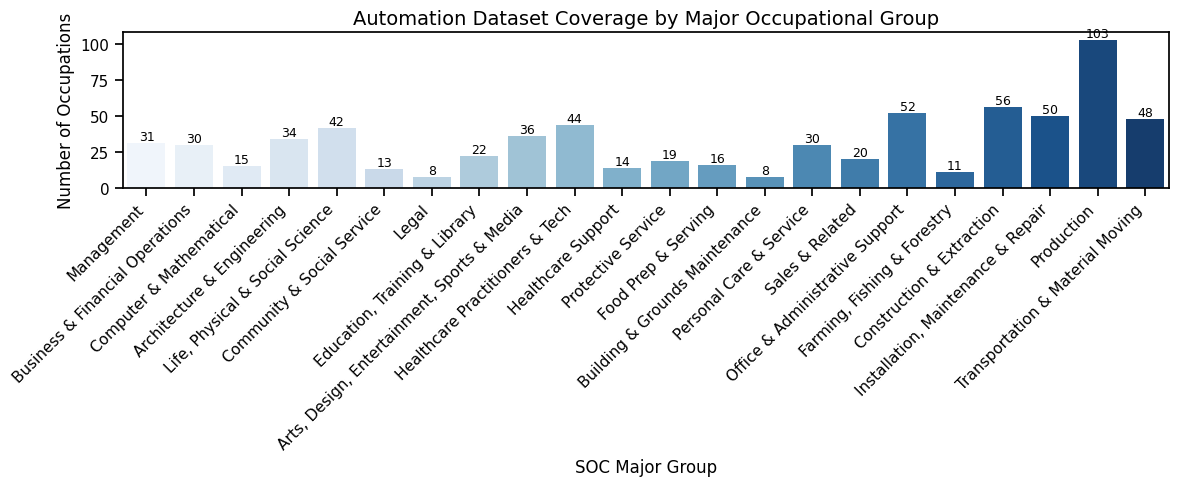

In [36]:
# Map SOC major-group codes to readable labels
soc_major_map = {
    '11': 'Management',
    '13': 'Business & Financial Operations',
    '15': 'Computer & Mathematical',
    '17': 'Architecture & Engineering',
    '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service',
    '23': 'Legal',
    '25': 'Education, Training & Library',
    '27': 'Arts, Design, Entertainment, Sports & Media',
    '29': 'Healthcare Practitioners & Tech',
    '31': 'Healthcare Support',
    '33': 'Protective Service',
    '35': 'Food Prep & Serving',
    '37': 'Building & Grounds Maintenance',
    '39': 'Personal Care & Service',
    '41': 'Sales & Related',
    '43': 'Office & Administrative Support',
    '45': 'Farming, Fishing & Forestry',
    '47': 'Construction & Extraction',
    '49': 'Installation, Maintenance & Repair',
    '51': 'Production',
    '53': 'Transportation & Material Moving',
}
# Build a tidy DataFrame for plotting with labels
group_df = (
    group_counts.reset_index().rename(columns={'index': 'major_group', 0: 'count'})
)
group_df['major_group'] = group_df['major_group'].astype(str).str.zfill(2)
group_df['label'] = group_df['major_group'].map(soc_major_map).fillna(group_df['major_group'])
# Plot with readable labels
plt.figure(figsize=(12,5))
ax = sns.barplot(x='label', y='count', data=group_df, palette='Blues')
plt.title('Automation Dataset Coverage by Major Occupational Group')
plt.xlabel('SOC Major Group')
plt.ylabel('Number of Occupations')
plt.xticks(rotation=45, ha='right')
# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Grouping the following smaller major groups into "Other": ['Community & Social Service', 'Legal', 'Building & Grounds Maintenance', 'Farming, Fishing & Forestry']


/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/3270532926.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='label_grouped', y='count', data=grouped, palette='Blues', order=grouped['label_grouped'])


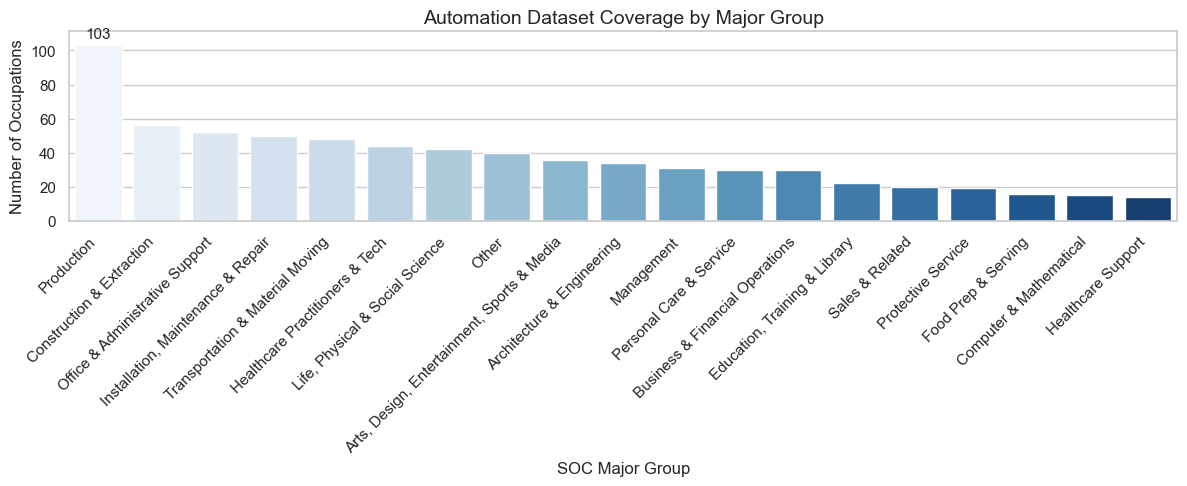

,label_grouped,count
0,Production,103
1,Construction & Extraction,56
2,Office & Administrative Support,52
3,"Installation, Maintenance & Repair",50
4,Transportation & Material Moving,48
5,Healthcare Practitioners & Tech,44
6,"Life, Physical & Social Science",42
7,Other,40
8,"Arts, Design, Entertainment, Sports & Media",36
9,Architecture & Engineering,34


In [44]:
# Group small SOC major groups into 'Other' and replot
# This cell keeps lesser (smaller-count) major groups as 'Other' for cleaner presentation
total_occ = group_df['count'].sum()
min_count = max(3, int(0.02 * total_occ))  # at least 3 or 2% of total occupations
small_groups = group_df[group_df['count'] < min_count]['label'].tolist()
print('Grouping the following smaller major groups into "Other":', small_groups)
group_df2 = group_df.copy()
group_df2['label_grouped'] = group_df2['label'].where(~group_df2['label'].isin(small_groups), 'Other')
grouped = group_df2.groupby('label_grouped', as_index=False)['count'].sum().sort_values('count', ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
ax = sns.barplot(x='label_grouped', y='count', data=grouped, palette='Blues')
plt.title('Automation Dataset Coverage by Major Group')
plt.xlabel('SOC Major Group')
plt.ylabel('Number of Occupations')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Also display the grouped counts as a small table for exact values
from IPython.display import display
display(grouped.reset_index(drop=True))

In [40]:
# Load salary dataset
df_salary = pd.read_excel("/Users/thetsusann/Desktop/BIA/Project/EDA/datasets/occupation-salary.xlsx")
df_salary.head()

,OCC_CODE,OCC_TITLE,OCC_GROUP,TOT_EMP,EMP_PRSE,H_MEAN,A_MEAN,MEAN_PRSE,H_PCT10,H_PCT25,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,00-0000,All Occupations,total,140400040,0.1,23.86,49630,0.1,9.27,11.6,17.81,28.92,45.45,19290,24140,37040,60150,94540,NaN,NaN
1,11-0000,Management Occupations,major,7090790,0.2,56.74,118020,0.1,22.76,32.99,48.46,70.72,#,47330,68630,100790,147090,#,NaN,NaN
2,11-1000,Top Executives,minor,2465800,0.2,61.03,126950,0.2,20.58,31.45,49.19,78.35,#,42810,65420,102320,162970,#,NaN,NaN
3,11-1010,Chief Executives,broad,223260,0.7,93.44,194350,0.4,33.55,54.86,87.12,#,#,69780,114100,181210,#,#,NaN,NaN
4,11-1011,Chief Executives,detailed,223260,0.7,93.44,194350,0.4,33.55,54.86,87.12,#,#,69780,114100,181210,#,#,NaN,NaN


In [41]:
# Basics
print("Total occupations:", df_salary.shape[0])
print("Unique SOC codes:", df_salary["OCC_CODE"].nunique())
print("Missing median salaries:", df_salary["A_MEDIAN"].isna().sum())
print("Missing employment values:", df_salary["TOT_EMP"].isna().sum())

Total occupations: 1394
Unique SOC codes: 1394
Missing median salaries: 0
Missing employment values: 0


Original non-null A_MEDIAN: 1394; After cleaning numeric: 1382; Lost: 12 (0.9% )


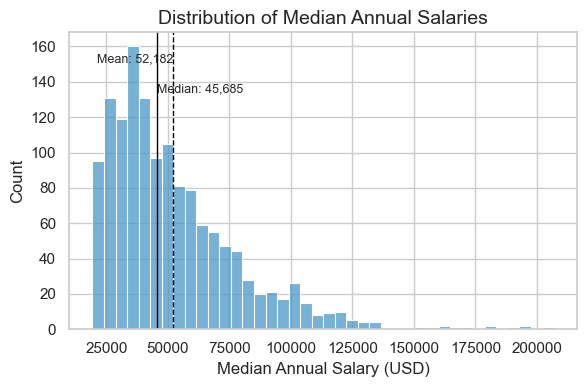

In [45]:
# Distribution of median annual salaries (cleaned, styled with seaborn)
import seaborn as sns
# Apply consistent Seaborn theme/context used across the notebook
sns.set_theme(style='whitegrid', palette='Blues')
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
plt.figure(figsize=(6,4))
# Clean A_MEDIAN: remove non-numeric characters and coerce to numeric
s = df_salary['A_MEDIAN'].astype(str).str.strip()
s_clean = s.str.replace(r"[^0-9.]", "", regex=True)
# Replace empty strings with NA so to_numeric will turn them into NaN
s_clean = s_clean.replace('', pd.NA)
s_num = pd.to_numeric(s_clean, errors='coerce')
orig_non_null = df_salary['A_MEDIAN'].notna().sum()
clean_non_null = s_num.notna().sum()
lost = orig_non_null - clean_non_null
pct = (lost / orig_non_null * 100) if orig_non_null else 0
print(f'Original non-null A_MEDIAN: {orig_non_null}; After cleaning numeric: {clean_non_null}; Lost: {lost} ({pct:.1f}% )')
# Plot using cleaned numeric series with consistent seaborn styling
ax = sns.histplot(s_num.dropna(), bins=40, kde=False, color=sns.color_palette('Blues', 4)[2], edgecolor='white')
# Add mean and median lines for context
mean_val = s_num.mean()
median_val = s_num.median()
if pd.notna(mean_val):
    ax.axvline(mean_val, color='k', linestyle='--', linewidth=1)
if pd.notna(median_val):
    ax.axvline(median_val, color='k', linestyle='-', linewidth=1)
# Annotate mean/median on the plot
ymax = ax.get_ylim()[1]
if pd.notna(mean_val):
    ax.text(mean_val, ymax * 0.9, f'Mean: {mean_val:,.0f}', ha='right', fontsize=9)
if pd.notna(median_val):
    ax.text(median_val, ymax * 0.8, f'Median: {median_val:,.0f}', ha='left', fontsize=9)
plt.title('Distribution of Median Annual Salaries')
plt.xlabel('Median Annual Salary (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Original non-null TOT_EMP: 1394; After cleaning numeric: 1394; Lost: 0 (0.0% )


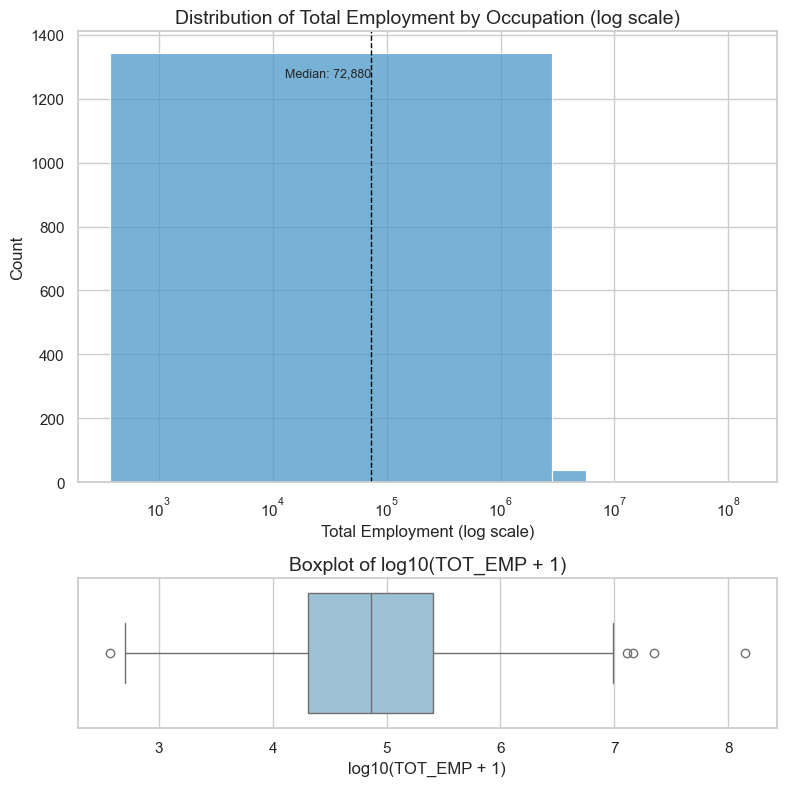

In [49]:
# Distribution of total employment by occupation (log-scaled + boxplot)
import seaborn as sns
import numpy as np
# Use consistent theme/context
sns.set_theme(style='whitegrid', palette='Blues')
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
# Clean TOT_EMP to numeric (remove commas/strings)
t = df_salary['TOT_EMP'].astype(str).str.replace(',', '').str.strip()
t = t.replace(['', 'nan', 'None', 'NA'], pd.NA)
t_num = pd.to_numeric(t, errors='coerce')
orig_non_null = df_salary['TOT_EMP'].notna().sum()
clean_non_null = t_num.notna().sum()
lost = orig_non_null - clean_non_null
pct = (lost / orig_non_null * 100) if orig_non_null else 0
print(f'Original non-null TOT_EMP: {orig_non_null}; After cleaning numeric: {clean_non_null}; Lost: {lost} ({pct:.1f}% )')
# Replace zeros with small positive for log plotting safety (keep original zeros if meaningful)
t_for_log = t_num.copy()
t_for_log = t_for_log.fillna(0)
t_for_log_nonneg = t_for_log.clip(lower=0)
# Create figure with histogram (log x-axis) and boxplot of log10(TOT_EMP+1)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8,8), gridspec_kw={'height_ratios':[3,1]})
ax = axes[0]
# Histogram with many bins, on log scale to show distribution across orders of magnitude
sns.histplot(t_for_log_nonneg.replace(0, np.nan).dropna(), bins=50, ax=ax, color=sns.color_palette('Blues', 4)[2], edgecolor='white')
ax.set_xscale('log')
ax.set_title('Distribution of Total Employment by Occupation (log scale)')
ax.set_xlabel('Total Employment (log scale)')
ax.set_ylabel('Count')
# Annotate median on histogram
median_val = t_num.median()
if pd.notna(median_val) and median_val > 0:
    ax.axvline(median_val, color='k', linestyle='--', linewidth=1)
    ax.text(median_val, ax.get_ylim()[1]*0.9, f'Median: {int(median_val):,}', ha='right', fontsize=9)
# Bottom: boxplot of log10(TOT_EMP + 1) to show spread and outliers
ax2 = axes[1]
log_series = np.log10(t_num.fillna(0) + 1)
sns.boxplot(x=log_series, ax=ax2, color=sns.color_palette('Blues', 4)[1])
ax2.set_xlabel('log10(TOT_EMP + 1)')
ax2.set_yticks([])
ax2.set_title('Boxplot of log10(TOT_EMP + 1)')
plt.tight_layout()
plt.show()

In [48]:
print("Lowest employment:", df_salary["TOT_EMP"].min())
print("Highest employment:", df_salary["TOT_EMP"].max())

Lowest employment: 370
Highest employment: 140400040


/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/1109766621.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


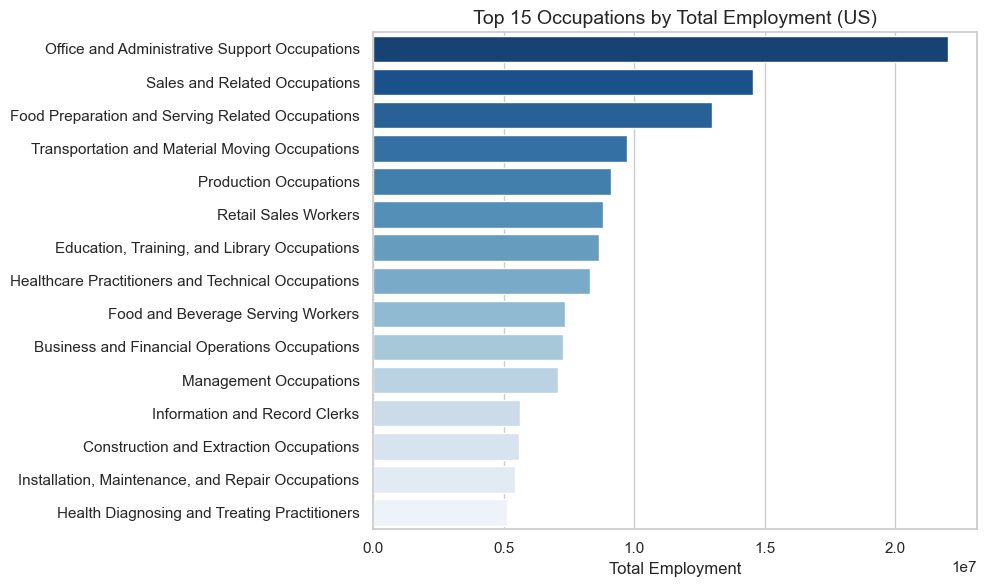

In [59]:
# Top 15 occupations by total employment (exclude summary rows like 'All Occupations')
# Clean TOT_EMP to numeric and exclude any summary/title rows
tclean = df_salary.copy()
# Normalize title column and drop obvious summary rows
tclean['OCC_TITLE_clean'] = tclean['OCC_TITLE'].astype(str).str.strip()
mask_summary = tclean['OCC_TITLE_clean'].str.lower().str.contains('all occupation|all occupations|total', na=False)
tclean = tclean[~mask_summary].copy()
# Ensure TOT_EMP numeric (remove commas)
tclean['TOT_EMP_num'] = pd.to_numeric(tclean['TOT_EMP'].astype(str).str.replace(',',''), errors='coerce')
# Select top 15 by cleaned TOT_EMP
top_emp = tclean.sort_values('TOT_EMP_num', ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
ax = sns.barplot(
    x=top_emp['TOT_EMP_num'],
    y=top_emp['OCC_TITLE_clean'],
    palette='Blues_r',
)
plt.title('Top 15 Occupations by Total Employment (US)')
plt.xlabel('Total Employment')
plt.ylabel('')
# # Annotate bars with formatted numbers
# try:
#     ax.bar_label(ax.containers[0], labels=[f'{int(x):,}' for x in top_emp['TOT_EMP_num']], padding=3)
# except Exception:
#     for i, val in enumerate(top_emp['TOT_EMP_num']):
#         plt.text(val + top_emp['TOT_EMP_num'].max()*0.01, i, f'{int(val):,}', va='center', fontsize=5)
plt.tight_layout()
plt.show()

A_PCT90 non-null before: 1394, after: 1336
A_PCT10 non-null before: 1394, after: 1388


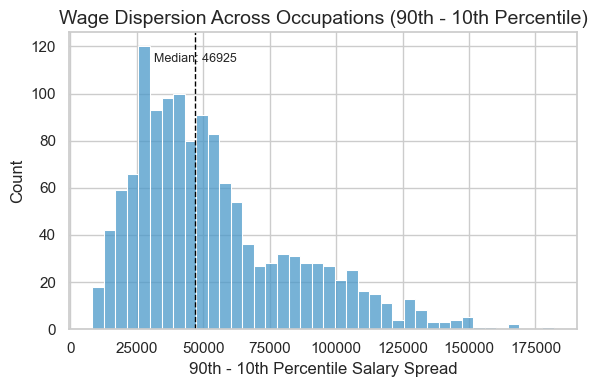

In [61]:
# Calculate wage spread (90th percentile - 10th percentile) with cleaning and plot (styled)
import seaborn as sns
# Clean percentile columns: remove non-numeric chars and coerce to numeric
p90 = df_salary['A_PCT90'].astype(str).str.strip()
p10 = df_salary['A_PCT10'].astype(str).str.strip()
p90_clean = p90.str.replace(r"[^0-9.]", "", regex=True).replace('', pd.NA)
p10_clean = p10.str.replace(r"[^0-9.]", "", regex=True).replace('', pd.NA)
p90_num = pd.to_numeric(p90_clean, errors='coerce')
p10_num = pd.to_numeric(p10_clean, errors='coerce')
# Report cleaning stats
print(f'A_PCT90 non-null before: {p90.notna().sum()}, after: {p90_num.notna().sum()}')
print(f'A_PCT10 non-null before: {p10.notna().sum()}, after: {p10_num.notna().sum()}')
# Compute wage spread and attach to DataFrame (numeric)
df_salary['wage_spread'] = p90_num - p10_num
# Styling and plot
sns.set_theme(style='whitegrid', palette='Blues')
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
plt.figure(figsize=(6,4))
ax = sns.histplot(df_salary['wage_spread'].dropna(), bins=40, color=sns.color_palette('Blues', 4)[2], edgecolor='white')
# Add median line for reference
median_ws = df_salary['wage_spread'].median()
if pd.notna(median_ws):
    ax.axvline(median_ws, color='k', linestyle='--', linewidth=1)
    ymax = ax.get_ylim()[1]
    ax.text(median_ws, ymax*0.9, f'Median: {median_ws:.0f}', ha='center', fontsize=9)
plt.title('Wage Dispersion Across Occupations (90th - 10th Percentile)')
plt.xlabel('90th - 10th Percentile Salary Spread')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Grouping small major groups into Other: ['23', '31', '37']


/var/folders/qj/sypsr4hs17z923tv3v1dkt3w0000gn/T/ipykernel_15268/4278995861.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='label_grouped', y='median', data=grouped, palette='Blues_r')


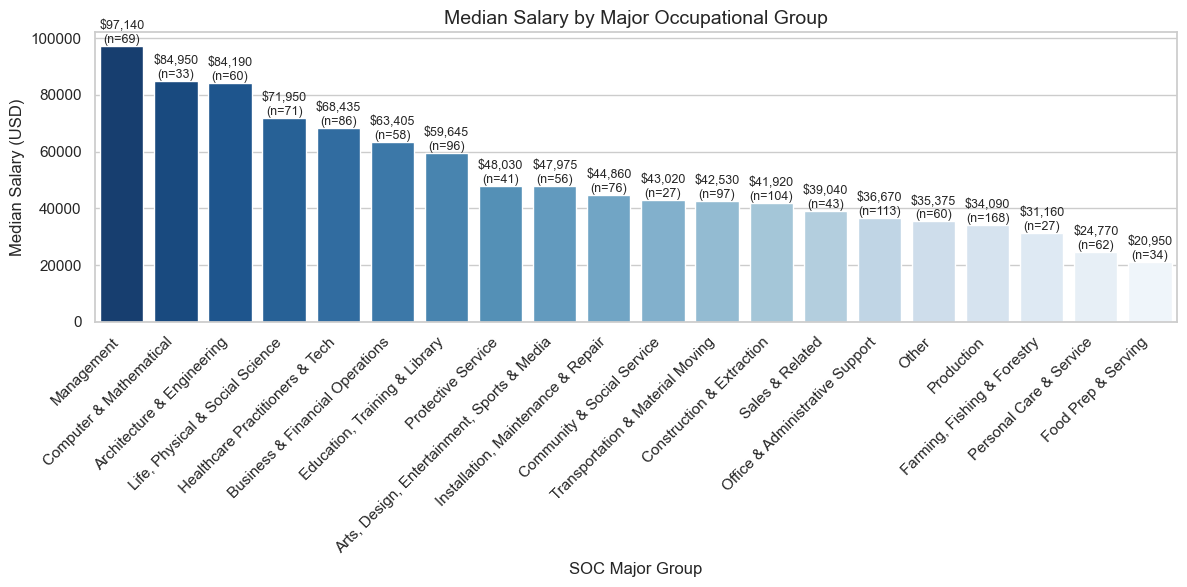

,label_grouped,median,count
0,Management,97140.0,69
1,Computer & Mathematical,84950.0,33
2,Architecture & Engineering,84190.0,60
3,"Life, Physical & Social Science",71950.0,71
4,Healthcare Practitioners & Tech,68435.0,86
5,Business & Financial Operations,63405.0,58
6,"Education, Training & Library",59645.0,96
7,Protective Service,48030.0,41
8,"Arts, Design, Entertainment, Sports & Media",47975.0,56
9,"Installation, Maintenance & Repair",44860.0,76


In [70]:
# Analyze median salary by major SOC groups (first 2 digits); remove '00' and group low-count groups into 'Other'
# Map SOC major-group numeric codes to human-readable labels
soc_major_map = {
    '11': 'Management',
    '13': 'Business & Financial Operations',
    '15': 'Computer & Mathematical',
    '17': 'Architecture & Engineering',
    '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service',
    '23': 'Legal',
    '25': 'Education, Training & Library',
    '27': 'Arts, Design, Entertainment, Sports & Media',
    '29': 'Healthcare Practitioners & Tech',
    '31': 'Healthcare Support',
    '33': 'Protective Service',
    '35': 'Food Prep & Serving',
    '37': 'Building & Grounds Maintenance',
    '39': 'Personal Care & Service',
    '41': 'Sales & Related',
    '43': 'Office & Administrative Support',
    '45': 'Farming, Fishing & Forestry',
    '47': 'Construction & Extraction',
    '49': 'Installation, Maintenance & Repair',
    '51': 'Production',
    '53': 'Transportation & Material Moving',
}

# Clean A_MEDIAN into numeric
s = df_salary['A_MEDIAN'].astype(str).str.strip()
s_clean = s.str.replace(r"[^0-9.\-]", "", regex=True)
s_clean = s_clean.replace('', pd.NA)
df_salary['A_MEDIAN_clean'] = pd.to_numeric(s_clean, errors='coerce')

# Major group (first 2 chars of OCC_CODE)
df_salary['major_group'] = df_salary['OCC_CODE'].astype(str).str[:2]

# Exclude '00' summary/placeholder rows
df2 = df_salary[df_salary['major_group'] != '00'].copy()

# Determine low-count groups to fold into 'Other'
total_occ = df2.shape[0]
min_count = max(3, int(0.02 * total_occ))  # at least 3 or 2% of rows
counts = df2.groupby('major_group').size().reset_index(name='count')
small_groups = counts[counts['count'] < min_count]['major_group'].tolist()
print('Grouping small major groups into Other:', small_groups)

# Create readable label for each row, grouping small ones as 'Other'
def label_for(code):
    if code in small_groups:
        return 'Other'
    return soc_major_map.get(code, code)

df2['label_grouped'] = df2['major_group'].apply(label_for)

# Aggregate median and counts by grouped label
grouped = (
    df2.groupby('label_grouped', observed=True)
       .agg(median=('A_MEDIAN_clean', 'median'), count=('A_MEDIAN_clean', 'count'))
       .reset_index()
)
# Drop groups with no numeric median
grouped = grouped.dropna(subset=['median'])
# Sort by median descending for plotting clarity
grouped = grouped.sort_values('median', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(12,6))
sns.set_context('notebook', rc={'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12})
ax = sns.barplot(x='label_grouped', y='median', data=grouped, palette='Blues_r')
plt.title('Median Salary by Major Occupational Group')
plt.xlabel('SOC Major Group')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=45, ha='right')
# Annotate with formatted currency and counts
for p, (med, cnt) in zip(ax.patches, zip(grouped['median'], grouped['count'])):
    try:
        ax.annotate(f'${int(med):,}\n(n={int(cnt)})', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
    except Exception:
        ax.annotate(f'${med:.0f}\n(n={int(cnt)})', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Display grouped table for exact values
from IPython.display import display
display(grouped)
